## CRCA for loading $p(t_i)$ into a quantum circuit

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from pathlib import Path
from quantum_cva.crca.crca_circuit import CrcaCircuit
from quantum_cva.circuit_training_tools import save_crca_training
from quantum_cva.circuit_training_tools import plot_training_diagnostics, minimize_with_cost_history
from scipy.optimize import minimize
from qiskit_algorithms.optimizers import SPSA

Target array

In [2]:
# Discount factor target array (the one obtained classically)
discount_factors_target =  np.asarray([
      1.0,
      0.9965983912172507,
      0.9932083533768123,
      0.9898298471188658
    ])


CRCA circuit building

In [3]:
m_time = 2
n_price = 0

In [4]:
crca = CrcaCircuit(
    m_time=m_time,
    n_price=n_price,
    n_layers=1,      
    name="CRCA_df",
)

qc = crca.qc

print(qc.draw(output="text", fold=120))

                                                                                                                     »
t_0: ───────────────────────────────────────────────────────■───────────────■───────────────■────────────────────────»
                                                            │               │               │                        »
t_1: ───────────────────────────────────────────────────────┼───────────────┼───────────────┼───────────────■────────»
     ┌──────────────┐┌──────────────┐┌──────────────┐┌──────┴───────┐┌──────┴───────┐┌──────┴───────┐┌──────┴───────┐»
  a: ┤ Ry(theta[0]) ├┤ Rz(theta[1]) ├┤ Ry(theta[2]) ├┤ Rx(theta[3]) ├┤ Ry(theta[4]) ├┤ Rz(theta[5]) ├┤ Rx(theta[6]) ├»
     └──────────────┘└──────────────┘└──────────────┘└──────────────┘└──────────────┘└──────────────┘└──────────────┘»
«                     
«t_0: ────────────────
«                     
«t_1: ───────■────────
«     ┌──────┴───────┐
«  a: ┤ Ry(theta[7]) ├
«     └──────────────┘


CRCA circuit training

In [5]:
# -------------------------
# Fixed hyperparameters
# -------------------------
SEED = 123
N_ITERS = 7000
METHOD = "COBYLA"

1. Ideal (statevector) setting

In [6]:
# RHOBEG can be different in the shots-based setting due to the stochastic nature of the problem
RHOBEG = 0.1
rng = np.random.default_rng(SEED)

# -------------------------
# Initial parameters
# -------------------------
x0 = rng.standard_normal(crca.n_params).astype(float)

# -------------------------
# Define L2 cost (ideal, statevector)
# -------------------------
cost = crca.cost_fn(discount_factors_target, shots=None)

# -------------------------
# Run optimization
# -------------------------
res = minimize(
    cost,
    x0=x0,
    method=METHOD,
    options={
        "maxiter": int(N_ITERS),
        "rhobeg": RHOBEG,
        "disp": True,
    },
)

theta_star = np.asarray(res.x, dtype=float)

# -------------------------
# Diagnostics
# -------------------------
f0 = crca.function_values(x0, shots=None)
f_star_statevector = crca.function_values(theta_star, shots=None)

C:\Users\guilb\Desktop\Quantum-CVA\src\quantum_cva\circuit_training_tools.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


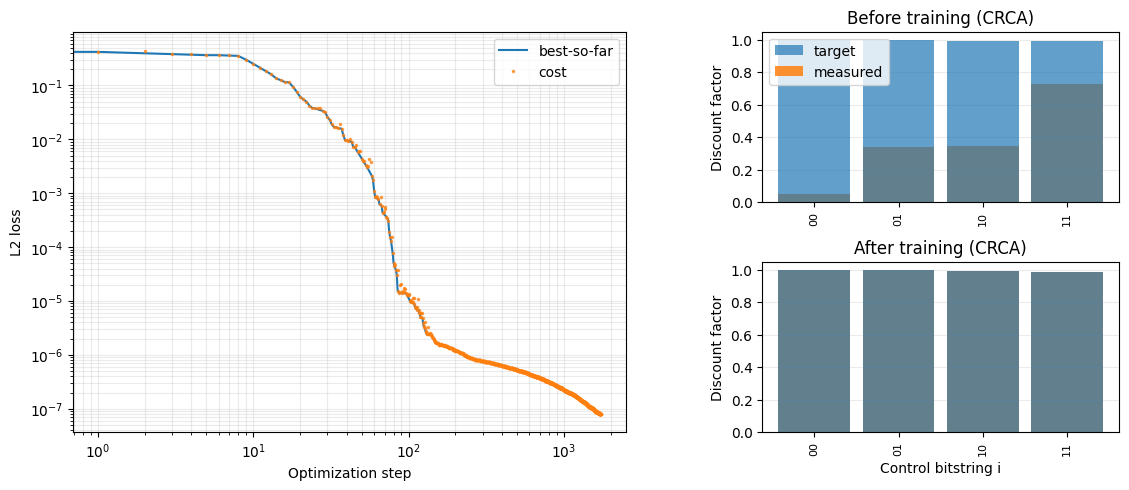

In [7]:
# --- rerun optimization capturing the history ---
res, cost_history = minimize_with_cost_history(
    cost,
    x0=x0,
    minimize_fn=minimize,
    method=METHOD,
    options={
        "maxiter": int(N_ITERS),
        "rhobeg": RHOBEG,
        "disp": True,
    },
)

theta_star = np.asarray(res.x, dtype=float)

# 2) Recompute before/after function values
f0 = crca.function_values(x0, shots=None)
f_star = crca.function_values(theta_star, shots=None)

# 3) best-so-far curve and indices
best_so_far = np.minimum.accumulate(cost_history)
tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

# 4) Labels (bitstrings of length n_controls)
labels = [format(i, f"0{crca.n_controls}b") for i in range(crca.dim_controls)]

plot_training_diagnostics(
    target=discount_factors_target,
    before=f0,
    after=f_star,
    cost_history=cost_history,
    best_so_far=best_so_far,
    best_idx=best_idx,
    labels=labels,
    xlabel="Control bitstring i",
    ylabel="Discount factor",
    cost_ylabel="L2 loss",
    title_before="Before training (CRCA)",
    title_after="After training (CRCA)",
    cost_log_x=True,
    cost_log_y=True
)

2. Shots-based setting

C:\Users\guilb\Desktop\Quantum-CVA\src\quantum_cva\circuit_training_tools.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


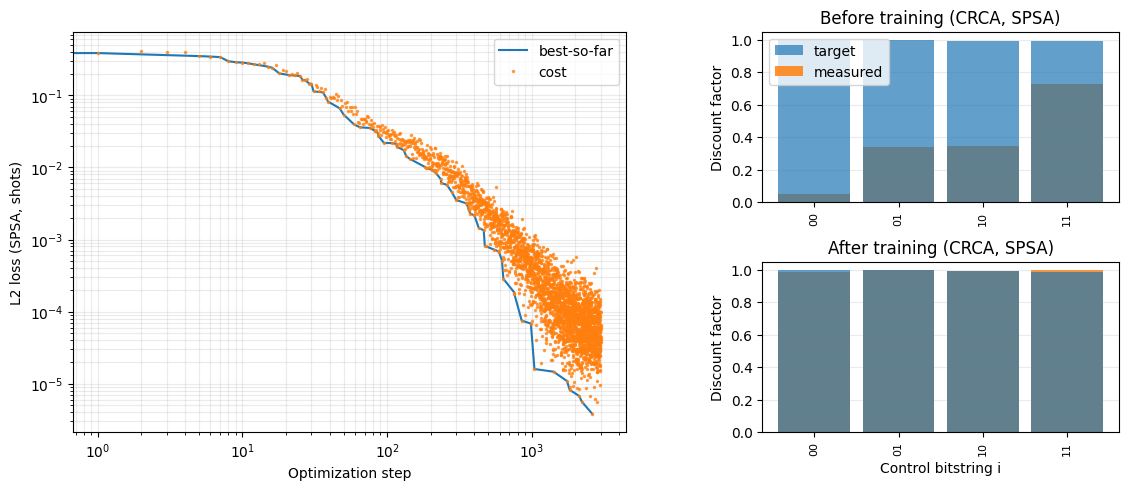

In [8]:
# =========================
# Shot-based training for CRCA with SPSA (simple scheduling)
# =========================
N_ITERS = 3000
SHOTS = 1000

# fixed-shot objective
cost_shots = crca.cost_fn(discount_factors_target, shots=SHOTS, seed=None)

cost_history: list[float] = []

# callback para registrar coste
def spsa_cb(nfev, x, fx, stepsize, accepted):
    cost_history.append(float(fx))

# -------------------------
# SPSA setup (constantes)
# -------------------------
opt = SPSA(
    maxiter=int(N_ITERS),
    learning_rate=0.08,      # tamaño de paso
    perturbation=0.12,       # tamaño de la perturbación
    blocking=False,          # evita congelar pasos
    trust_region=True,       # estabiliza pasos grandes
    callback=spsa_cb,
)


# -------------------------
# Run optimization
# -------------------------
res = opt.minimize(fun=cost_shots, x0=x0)
theta_star = np.asarray(res.x, dtype=float)

# -------------------------
# Diagnostics
# -------------------------
f_star_shots  = crca.function_values(theta_star, shots=SHOTS, seed=None)

# -------------------------
# Cost history + best-so-far
# -------------------------
cost_history = np.asarray(cost_history, dtype=float)
best_so_far = np.minimum.accumulate(cost_history)
tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

labels = [format(i, f"0{crca.n_controls}b") for i in range(crca.dim_controls)]

plot_training_diagnostics(
    target=discount_factors_target,
    before=f0,
    after=f_star_shots,
    cost_history=cost_history,
    best_so_far=best_so_far,
    best_idx=best_idx,
    labels=labels,
    xlabel="Control bitstring i",
    ylabel="Discount factor",
    cost_ylabel="L2 loss (SPSA, shots)",
    title_before="Before training (CRCA, SPSA)",
    title_after="After training (CRCA, SPSA)",
    cost_log_x=True,
    cost_log_y=True,
)

Save data

In [9]:
OUTDIR = Path("../../../data/crca/discount_factors")

npz_path, json_path = save_crca_training(
    f_trained=f_star,                          # shot-based trained
    f_statevector=f_star_statevector,          # ideal result
    f_target=discount_factors_target,
    filename_stem="crca_discount_factor_spsa_shots",
    outdir=OUTDIR,
    metadata={
        # --- Model identity ---
        "model": "CRCA",
        "task": "discount_factor",
        "ancilla_observable": "P(a=1 | control=i)",

        # --- Circuit structure ---
        "m_time": crca.m_time,
        "n_price": crca.n_price,
        "n_controls": crca.n_controls,
        "n_layers": crca.n_layers,
        "n_parameters": crca.n_params,

        # --- Optimizer identity ---
        "optimizer": "SPSA",
        "optimizer_library": "qiskit-algorithms",

        # --- Optimizer hyperparameters ---
        "learning_rate": 0.08,
        "perturbation": 0.12,
        "maxiter": int(N_ITERS),
        "blocking": False,
        "trust_region": True,

        # --- Objective / noise model ---
        "cost_function": "L2",
        "shots": SHOTS,
        "stochastic_cost": True,
        "shot_seed": None,

        # --- Ideal reference ---
        "statevector_reference": True,

        # --- Run semantics ---
        "stopping_criterion": "maxiter",
        "note": (
            "CRCA discount-factor training. "
            "NPZ contains both shot-based trained values and ideal statevector reference."
        ),
    }
)